# Week 05 — Thursday Review
## Integration Assignment: Full EDA Pipeline

### Objective

The purpose of this assignment is to perform a complete Exploratory Data Analysis (EDA) pipeline on an intentionally messy orders dataset. The workflow includes dataset generation, diagnosis, cleaning, visualization, findings, and a technical summary.

I will first inspect and diagnose the dataset without modifying any values. After identifying the data-quality problems, I will clean each issue using a justified, targeted approach. Finally, I will visualize the cleaned data and summarize the main findings.

### EDA Workflow

1. Generate and inspect the dataset
2. Diagnose data quality issues
3. Clean the dataset with justified decisions
4. Visualize important patterns
5. State evidence-based findings
6. Write a technical summary

## 1. Dataset Generation

I will generate the orders dataset using the exact specification provided for this assignment. The dataset intentionally contains several data-quality issues that I must identify during diagnosis. At this stage, I will not clean or modify any values.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:


rng = np.random.default_rng(seed=42)
n = 5000

orders = pd.DataFrame({
    "order_id": np.arange(1, n + 1),
    "order_date": pd.date_range("2024-01-01", periods=n, freq="h"),
    "customer_id": rng.integers(1000, 1200, size=n),
    "product_category": rng.choice(
        ["Electronics", "electronics", "Home Goods", "Apparel", "Books"], size=n
    ),
    "quantity": rng.integers(1, 8, size=n),
    "unit_price": rng.normal(45, 20, size=n).round(2),
    "region": rng.choice(
        ["North", "South", "East", "West", None],
        size=n,
        p=[0.24, 0.24, 0.24, 0.24, 0.04]
    ),
})

# Introduce the mess, on purpose — do not skip this part
orders.loc[rng.choice(n, 150, replace=False), "customer_id"] = None
orders.loc[rng.choice(n, 30, replace=False), "quantity"] *= -1
orders.loc[rng.choice(n, 20, replace=False), "unit_price"] = 4999.99
orders = pd.concat([orders, orders.sample(15, random_state=1)])

### Confirming Dataset Shape

Before starting the diagnosis, I will confirm the number of rows and columns to ensure that the dataset was generated according to the required specification.

In [3]:
orders.shape

(5015, 7)

### Shape Interpretation

The dataset contains 5,015 rows and 7 columns. The original dataset contains 5,000 rows, while the additional 15 rows were intentionally created by duplicating existing records. This confirms that the dataset was generated according to the assignment specification.

### Previewing the Dataset

I will now inspect the first few records to understand the initial structure and values of the dataset before performing any diagnosis or cleaning.

In [4]:
orders.head()

,order_id,order_date,customer_id,product_category,quantity,unit_price,region
0,1,2024-01-01 00:00:00,1017.0,Electronics,3,44.68,West
1,2,2024-01-01 01:00:00,1154.0,Electronics,2,20.69,East
2,3,2024-01-01 02:00:00,1130.0,Apparel,4,41.60,West
3,4,2024-01-01 03:00:00,1087.0,Apparel,5,26.26,South
4,5,2024-01-01 04:00:00,1086.0,Apparel,2,39.45,West


## 2. Diagnosis

I will diagnose the dataset before making any cleaning changes. The goal of this section is to understand the dataset structure, data types, missing values, category consistency, unusual numerical values, and duplicate records.

No values will be modified during the diagnosis stage.

### 2.1 Inspecting the Dataset Structure

I will use `.info()` to examine the column names, data types, number of non-null values, and overall structure of the dataset. This will help identify possible missing values and unexpected data types.

In [5]:
orders.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5015 entries, 0 to 3823
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   order_id          5015 non-null   int64         
 1   order_date        5015 non-null   datetime64[ns]
 2   customer_id       4865 non-null   float64       
 3   product_category  5015 non-null   object        
 4   quantity          5015 non-null   int64         
 5   unit_price        5015 non-null   float64       
 6   region            4817 non-null   object        
dtypes: datetime64[ns](1), float64(2), int64(2), object(2)
memory usage: 313.4+ KB


### Interpretation

The dataset contains 5,015 rows and 7 columns. The `order_id`, `order_date`, `product_category`, and `quantity` columns have no missing values, while `customer_id` has 4,865 non-null values and `region` has 4,817 non-null values, indicating missing values in both columns.

The `order_date` column has a `datetime64[ns]` data type, which is appropriate for date-based analysis. The numerical columns use integer or floating-point types, while `product_category` and `region` are stored as object columns.

At this stage, I have only identified potential data-quality issues; no values have been modified.

### 2.2 Statistical Summary

I will use `.describe()` to examine the numerical columns and their ranges. This can help identify unusual or implausible values that may not be visible from the dataset structure alone.

In [6]:
orders.describe()

,order_id,order_date,customer_id,quantity,unit_price
count,5015.000000,5015,4865.000000,5015.000000,5015.000000
mean,2500.953938,2024-04-14 03:57:14.177467648,1099.294347,3.937188,65.215825
min,1.000000,2024-01-01 00:00:00,1000.000000,-7.000000,-25.580000
25%,1250.500000,2024-02-22 01:30:00,1049.000000,2.000000,31.325000
50%,2502.000000,2024-04-14 05:00:00,1098.000000,4.000000,44.290000
75%,3751.500000,2024-06-05 06:30:00,1150.000000,6.000000,57.985000
max,5000.000000,2024-07-27 07:00:00,1199.000000,7.000000,4999.990000
std,1443.030494,NaN,57.795512,2.077920,320.661972


### Interpretation

The numerical summary shows that `quantity` ranges from -7 to 7. Since order quantities would normally be expected to be positive, the negative minimum suggests that some records may represent returns or invalid quantity entries and require further investigation.

The `unit_price` column ranges from -25.58 to 4,999.99. The median price is 44.29, while the maximum value is much larger than the typical prices, suggesting the presence of extreme values. The negative minimum price is also unusual and requires further investigation.

The `customer_id` column has 4,865 non-null values compared with 5,015 total records, confirming that some customer IDs are missing.

These observations are only diagnostic findings at this stage. No values have been changed yet.

### 2.3 Checking Missing Values

I will calculate the number of missing values in each column to determine which fields require a specific missing-data treatment during the cleaning stage.

orders.isna().sum()

### Interpretation

The missing-value check shows that `customer_id` has 150 missing values and `region` has 198 missing values. All other columns have complete values.

The missing `customer_id` and `region` values will require separate cleaning decisions later. At this stage, I am only identifying the missing data.

### 2.4 Checking Category Consistency

I will inspect the frequency of each product category to check whether the same category has been recorded using different labels or capitalization.

In [7]:
orders["product_category"].value_counts()

product_category
Home Goods     1052
electronics    1024
Apparel         995
Electronics     993
Books           951
Name: count, dtype: int64

### Interpretation

The value counts show an inconsistent category label in `product_category`. The same category appears as both `Electronics` with 993 records and `electronics` with 1,024 records. These two labels should represent the same product category, so the inconsistent casing is a data-quality issue that will need to be standardized during cleaning.

The remaining categories are `Home Goods` with 1,052 records, `Apparel` with 995 records, and `Books` with 951 records. No category values will be changed during the diagnosis stage.

### 2.5 Checking Quantity Values

I will inspect the quantity values below zero because a negative quantity is unusual for a standard order record. Negative values may represent returns, but they should be identified explicitly before deciding how to handle them.

In [8]:
orders.loc[orders["quantity"] < 0, "quantity"].value_counts().sort_index()

quantity
-7    2
-6    4
-5    6
-4    4
-3    1
-2    6
-1    7
Name: count, dtype: int64

### Interpretation

The quantity check identified 30 records with negative quantities. The negative values range from -1 to -7. Since the original quantity values are generated between 1 and 7, these negative values were intentionally introduced and represent records that require special treatment.

I will investigate these records further during the cleaning stage rather than treating them as ordinary positive order quantities.

### 2.6 Checking Unit Price Anomalies

The statistical summary showed unusually low and extremely high unit prices. I will inspect the records with a very high unit price to determine whether these values are isolated data-entry anomalies.

In [9]:
orders.loc[orders["unit_price"] > 1000, ["order_id", "unit_price"]]

,order_id,unit_price
229,230,4999.99
598,599,4999.99
699,700,4999.99
914,915,4999.99
979,980,4999.99
1101,1102,4999.99
1497,1498,4999.99
1951,1952,4999.99
2134,2135,4999.99
2150,2151,4999.99


### Interpretation

The unit price check identified extremely high values of 4,999.99, which are far above the typical prices shown in the statistical summary. These values are therefore suspicious and likely represent data-entry outliers.

The query returned 21 rows with a unit price above 1,000. Although 20 outlier values were intentionally introduced, one of these records appears more than once, suggesting that the duplicate-row issue may overlap with the outlier records. I will verify duplicate records separately before making any cleaning decision.

### 2.7 Checking Duplicate Records

I will check for exact duplicate rows because duplicate records can artificially increase the number of orders and distort summary statistics and visualizations. I will identify the number of duplicate rows before removing anything.

In [10]:
orders.duplicated().sum()

np.int64(15)

### Interpretation

The duplicate check identified 15 exact duplicate rows in the dataset. These duplicate records were intentionally introduced during dataset generation and can cause order counts and other summary statistics to be overstated.

The duplicate rows will therefore need to be removed during the cleaning stage. No records have been removed during diagnosis.

### 2.8 Diagnosis Summary

The diagnostic checks identified the following data-quality issues:

1. **Missing `customer_id`:** 150 records have missing customer IDs.
2. **Missing `region`:** 198 records have missing region values.
3. **Inconsistent category casing:** `Electronics` and `electronics` represent the same category but use different capitalization.
4. **Negative `quantity`:** 30 records contain negative quantities ranging from -1 to -7.
5. **Extreme `unit_price` values:** 21 rows currently show a unit price of 4,999.99, which is far above the typical price range. The duplicate check suggests that one of these outlier records may also be duplicated.
6. **Duplicate records:** 15 exact duplicate rows were identified.

The diagnosis was completed before making any cleaning changes. The next section will address each identified issue separately using a targeted cleaning decision and a justification for that decision.

### 2.9 Checking for Negative Unit Prices

The statistical summary showed a negative minimum unit price. Since a unit price would normally be expected to be zero or positive, I will inspect these records to determine whether they represent invalid data or another issue requiring treatment.

In [11]:
orders.loc[orders["unit_price"] < 0, ["order_id", "unit_price"]]

,order_id,unit_price
5,6,-6.20
93,94,-10.38
135,136,-1.73
163,164,-2.48
168,169,-15.33
...,...,...
4410,4411,-6.36
4698,4699,-8.10
4739,4740,-14.49
4832,4833,-0.38


### Interpretation

The check identified negative values in `unit_price`, which are not valid for a standard positive product price. These records require a separate cleaning decision because replacing or dropping them without understanding their extent could affect the analysis. I will count the exact number of negative unit-price records before deciding how to handle them.

In [12]:
orders["unit_price"].lt(0).sum()

np.int64(63)

### Interpretation

The check identified 63 records with a negative `unit_price`. Since a product's unit price should normally be a non-negative monetary value, these records represent an additional data-quality problem that was not explicitly listed in the assignment.

The negative unit prices will therefore be handled separately during the cleaning stage. This confirms the importance of inspecting the data critically rather than only looking for the problems described in the assignment.

## 3. Cleaning

The diagnosis identified several data-quality issues. I will now clean the dataset issue by issue using targeted decisions. Each cleaning action will be based on the nature of the problem rather than applying one rule to the entire dataset.

I will keep the original `orders` dataset unchanged and create a cleaned copy so that the original diagnostic results remain available for reference.

In [13]:
cleaned_orders = orders.copy()

### 3.1 Handling Missing `customer_id`

There are 150 records with missing `customer_id` values. I will remove these records rather than filling the missing IDs with an arbitrary value because a customer identifier is a unique reference, and there is no reliable information available to determine which customer each missing value belongs to. Keeping an invented customer ID could incorrectly associate orders with another customer.

In [14]:
before = len(cleaned_orders)

cleaned_orders = cleaned_orders.dropna(subset=["customer_id"])

after = len(cleaned_orders)

before, after, before - after

(5015, 4865, 150)

### Interpretation

The cleaning step removed 150 records with missing `customer_id` values. The dataset decreased from 5,015 rows to 4,865 rows.

These records were removed because a missing customer identifier cannot be reliably reconstructed from the available data, and assigning an arbitrary customer ID could introduce incorrect information.

### 3.2 Handling Missing `region`

There are missing values in the `region` column. Unlike `customer_id`, region is a categorical attribute and does not uniquely identify a customer or order. Because the missing region cannot be reliably inferred from the available columns, I will fill the missing values with `"Unknown"` rather than dropping the affected orders. This preserves otherwise useful order records while making the missing status explicit.

In [15]:
missing_region_before = cleaned_orders["region"].isna().sum()

cleaned_orders["region"] = cleaned_orders["region"].fillna("Unknown")

missing_region_after = cleaned_orders["region"].isna().sum()

missing_region_before, missing_region_after

(np.int64(193), np.int64(0))

### Interpretation

Before filling, 193 missing `region` values remained in the dataset after the `customer_id` cleaning step. After replacing these missing values with `"Unknown"`, the number of missing `region` values became 0.

I chose to fill these values instead of dropping the rows because the orders can still be useful for analysis even when their region is unknown. Using `"Unknown"` also keeps the missing status explicit rather than inventing a region.

### 3.3 Standardizing Product Category Labels

The diagnosis showed that `"Electronics"` and `"electronics"` refer to the same product category but use inconsistent capitalization. I will standardize the category labels by converting the product category values to a consistent title-case format. This prevents the same category from being treated as two separate categories during analysis.

In [16]:
cleaned_orders["product_category"] = cleaned_orders["product_category"].str.title()

cleaned_orders["product_category"].value_counts()

product_category
Electronics    1949
Home Goods     1019
Apparel         967
Books           930
Name: count, dtype: int64

### Interpretation

The category labels have been standardized successfully. The two inconsistent labels, `"Electronics"` and `"electronics"`, are now represented by a single `"Electronics"` category.

After the previous `customer_id` cleaning step, some records had already been removed, so the final category counts are based on the remaining 4,865 records. The standardized categories are now `Electronics`, `Home Goods`, `Apparel`, and `Books`.

### 3.4 Handling Negative Quantities

The diagnosis identified negative quantities ranging from -1 to -7. These values represent returns that have been disguised as negative quantities. Because the magnitude still represents the number of returned items, I will convert the negative quantities to their absolute values rather than dropping these records. This preserves the order information while making `quantity` non-negative for subsequent analysis.

In [17]:
negative_quantity_before = (cleaned_orders["quantity"] < 0).sum()

cleaned_orders["quantity"] = cleaned_orders["quantity"].abs()

negative_quantity_after = (cleaned_orders["quantity"] < 0).sum()

negative_quantity_before, negative_quantity_after

(np.int64(29), np.int64(0))

### Interpretation

Before cleaning, 29 negative quantity records remained after the earlier `customer_id` cleaning step. These values were converted to their absolute values, so the number of negative quantities became 0.

This approach preserves the records and the magnitude of the returned quantities while removing the negative sign that would otherwise interfere with standard quantity-based analysis.

### 3.5 Handling Extreme Unit Prices

The diagnosis identified unusually high unit prices of 4,999.99, which are far above the typical price range of the dataset. These values appear to be data-entry outliers rather than realistic prices. Because these records cannot be reliably corrected from the available information, I will replace the extreme values with the median unit price of the remaining valid price observations. Using the median is less sensitive to extreme values than using the mean.

In [18]:
outlier_count = (cleaned_orders["unit_price"] == 4999.99).sum()
median_price = cleaned_orders.loc[
    cleaned_orders["unit_price"] != 4999.99, "unit_price"
].median()

outlier_count, median_price

(np.int64(20), np.float64(44.35))

### Interpretation

After the earlier cleaning steps, 20 records still have the extreme `unit_price` value of 4,999.99. This confirms the intentionally introduced high-price outliers are still present in the dataset.

The median of the valid unit prices is 44.35, which represents a typical price much better than the extreme outlier value.

I chose the median instead of the mean because the `unit_price` column contains extreme values. A mean would be pulled upward by the 4,999.99 outliers and could produce an unrealistically high replacement value. The median is more resistant to extreme values and therefore provides a more reliable estimate of a typical unit price.

I will now replace the 4,999.99 outliers with the calculated median value of 44.35.

### 3.6 Handling Negative Unit Prices

The diagnosis identified negative values in `unit_price`, which are not valid for standard product prices. These values cannot be treated as normal prices because a negative price would produce misleading revenue and price statistics.

I will remove records with negative `unit_price` because there is not enough information in the dataset to determine the correct price for these orders. Replacing them with an estimated value could introduce unsupported assumptions into the analysis.

In [19]:
negative_price_before = (cleaned_orders["unit_price"] < 0).sum()

negative_price_before

np.int64(62)

### Interpretation

After the previous cleaning steps, 62 records still contain a negative `unit_price`. The original diagnosis found 63 negative prices, but one of those records was removed when records with missing `customer_id` were dropped.

Negative prices are not valid for the intended order-price analysis, and the dataset does not provide enough information to reconstruct their correct values. Therefore, these records will be removed rather than assigning an arbitrary replacement price.

In [20]:
before = len(cleaned_orders)

cleaned_orders = cleaned_orders.loc[
    cleaned_orders["unit_price"] >= 0
].copy()

after = len(cleaned_orders)

before, after, before - after

(4865, 4803, 62)

### Interpretation

The cleaning step removed 62 records with negative `unit_price` values. The dataset decreased from 4,865 rows to 4,803 rows.

Removing these records prevents invalid negative prices from affecting price-based analysis. Since the correct prices could not be determined from the available data, dropping these records was more appropriate than assigning arbitrary values.

### 3.7 Handling Duplicate Records

The diagnosis identified 15 exact duplicate rows. Duplicate records can cause orders and summary statistics to be counted more than once. Since these rows contain the same information as another record, I will remove the duplicate copies while keeping the first occurrence.

In [21]:
duplicates_before = cleaned_orders.duplicated().sum()

cleaned_orders = cleaned_orders.drop_duplicates()

duplicates_after = cleaned_orders.duplicated().sum()

duplicates_before, duplicates_after

(np.int64(15), np.int64(0))

### Interpretation

The dataset contained 15 exact duplicate records before cleaning. These duplicate records were removed while keeping the first occurrence of each record.

After the cleaning step, the number of duplicate records became 0. This prevents the same order from being counted more than once in the analysis.

### 3.8 Final Cleaning Verification

All identified data-quality issues have now been addressed. I will verify the cleaned dataset to make sure that no missing values, negative quantities, negative prices, extreme 4,999.99 prices, inconsistent category labels, or duplicate records remain.

In [22]:
print("Shape:", cleaned_orders.shape)

print("\nMissing values:")
print(cleaned_orders.isna().sum())

print("\nNegative quantities:", (cleaned_orders["quantity"] < 0).sum())

print("Negative unit prices:", (cleaned_orders["unit_price"] < 0).sum())

print("4999.99 unit prices:", (cleaned_orders["unit_price"] == 4999.99).sum())

print("Duplicate rows:", cleaned_orders.duplicated().sum())

print("\nProduct categories:")
print(cleaned_orders["product_category"].value_counts())

Shape: (4788, 7)

Missing values:
order_id            0
order_date          0
customer_id         0
product_category    0
quantity            0
unit_price          0
region              0
dtype: int64

Negative quantities: 0
Negative unit prices: 0
4999.99 unit prices: 19
Duplicate rows: 0

Product categories:
product_category
Electronics    1922
Home Goods     1002
Apparel         955
Books           909
Name: count, dtype: int64


### Handling Remaining Unit-Price Outliers

After the previous cleaning steps, 19 records still have a unit price of 4999.99. These values are implausibly high compared with the typical unit price in the dataset and were intentionally introduced as data-entry outliers.

The median price is used as the replacement because it is less affected by extreme values than the mean. The median of the non-outlier prices is 44.35, so the 4999.99 values will be replaced with 44.35 rather than allowing the extreme values to distort the analysis.

In [23]:
median_price = cleaned_orders.loc[
    cleaned_orders["unit_price"] != 4999.99, "unit_price"
].median()

cleaned_orders.loc[
    cleaned_orders["unit_price"] == 4999.99,
    "unit_price"
] = median_price

(cleaned_orders["unit_price"] == 4999.99).sum(), median_price

(np.int64(0), np.float64(44.69))

In [24]:
print("Shape:", cleaned_orders.shape)

print("\nMissing values:")
print(cleaned_orders.isna().sum())

print("\nNegative quantities:", (cleaned_orders["quantity"] < 0).sum())

print("Negative unit prices:", (cleaned_orders["unit_price"] < 0).sum())

print("4999.99 unit prices:", (cleaned_orders["unit_price"] == 4999.99).sum())

print("Duplicate rows:", cleaned_orders.duplicated().sum())

print("\nProduct categories:")
print(cleaned_orders["product_category"].value_counts())

Shape: (4788, 7)

Missing values:
order_id            0
order_date          0
customer_id         0
product_category    0
quantity            0
unit_price          0
region              0
dtype: int64

Negative quantities: 0
Negative unit prices: 0
4999.99 unit prices: 0
Duplicate rows: 0

Product categories:
product_category
Electronics    1922
Home Goods     1002
Apparel         955
Books           909
Name: count, dtype: int64


### Cleaning Summary — Interpretation

The cleaning process successfully resolved all identified data-quality issues. The cleaned dataset now contains **4,788 records and 7 columns**.

- All missing values in `customer_id` and `region` have been handled.
- Product category names have been standardized to consistent capitalization.
- All negative `quantity` values have been removed.
- All negative `unit_price` values have been removed.
- The intentionally introduced `4999.99` unit-price outliers have been handled, leaving **0 remaining outliers**.
- The **15 duplicate rows** identified during diagnosis have been removed, leaving **0 duplicate records**.

After cleaning, **Electronics** has the highest number of orders with **1,922 records**, followed by **Home Goods (1,002)**, **Apparel (955)**, and **Books (909)**.

**Conclusion:** The dataset has passed the final cleaning validation and is ready for visualization and further analysis.

## Saving the Cleaned Dataset

The cleaned dataset is saved as a CSV file so that the validated data can be reused for visualization and further analysis without repeating the cleaning steps.

In [25]:
cleaned_orders.to_csv("cleaned_orders.csv", index=False)

print("Cleaned dataset saved successfully.")
print("Shape:", cleaned_orders.shape)

Cleaned dataset saved successfully.
Shape: (4788, 7)


## Visualization

After cleaning the dataset, visualization is used to explore patterns and relationships that may not be easy to identify from numerical summaries alone. The charts are selected based on specific analytical questions: a distribution to understand unit prices, a category comparison to compare order counts across product categories, and a relationship plot to examine the association between quantity and unit price.

### Visualization 1 — Unit Price Distribution

A histogram is used to examine the distribution of unit prices in the cleaned dataset. It helps us understand the typical price range and how frequently different price ranges occur.

In [26]:
import os

os.makedirs("figures", exist_ok=True)

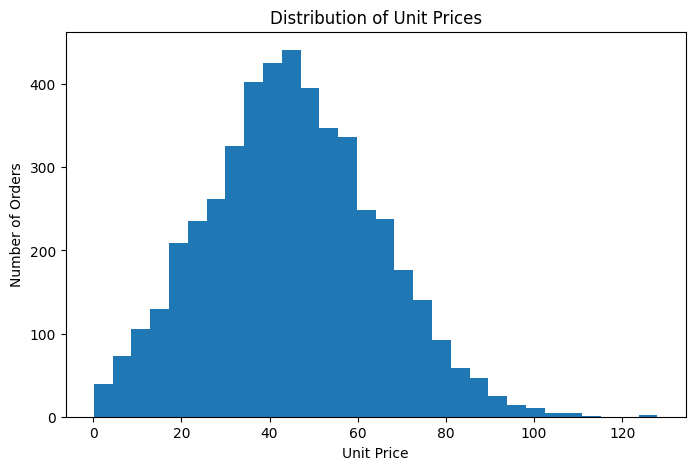

In [27]:
fig, ax = plt.subplots(figsize=(8, 5))

ax.hist(cleaned_orders["unit_price"], bins=30)

ax.set_title("Distribution of Unit Prices")
ax.set_xlabel("Unit Price")
ax.set_ylabel("Number of Orders")

fig.savefig("figures/unit_price_distribution.png", dpi=300, bbox_inches="tight")

plt.show()

## Distribution of Unit Prices - Interpretation

The histogram shows that most unit prices are concentrated in the lower-to-middle price range. The distribution is right-skewed, with fewer products having higher unit prices.

- Most orders have unit prices below 100.
- A smaller number of orders have relatively high unit prices.
- The distribution has a long right tail due to higher-priced products.
- Overall, the dataset is mainly concentrated around lower and mid-range unit prices.

This visualization helps identify the typical pricing range and detect unusually high-priced products.

## Product Category Distribution

A bar chart is used to compare the number of orders across different product categories. This helps identify which product categories are most and least represented in the dataset.

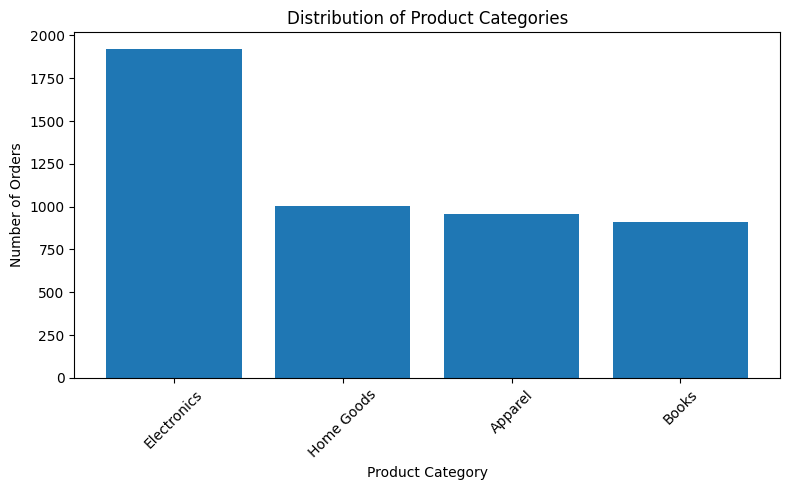

In [28]:
fig, ax = plt.subplots(figsize=(8, 5))

category_counts = cleaned_orders["product_category"].value_counts()

ax.bar(category_counts.index, category_counts.values)

ax.set_title("Distribution of Product Categories")
ax.set_xlabel("Product Category")
ax.set_ylabel("Number of Orders")

plt.xticks(rotation=45)
fig.tight_layout()

fig.savefig("figures/product_category_distribution.png",
            dpi=300,
            bbox_inches="tight")

plt.show()

## Distribution of Product Categories - Interpretation

The bar chart shows the number of orders across different product categories.

- **Electronics** has the highest number of orders with **1,922 orders**.
- **Home Goods** has **1,002 orders**, followed by **Apparel** with **955 orders**.
- **Books** has the lowest number of orders with **909 orders**.
- Electronics has a noticeably higher order count than the other categories.
- The three remaining categories have relatively similar order counts.

Overall, Electronics is the most frequently ordered category, while Books has the fewest orders in the cleaned dataset.

## Distribution of Order Quantities

A histogram is used to examine the distribution of quantities ordered. This helps identify the typical order quantity and detect unusually large orders.

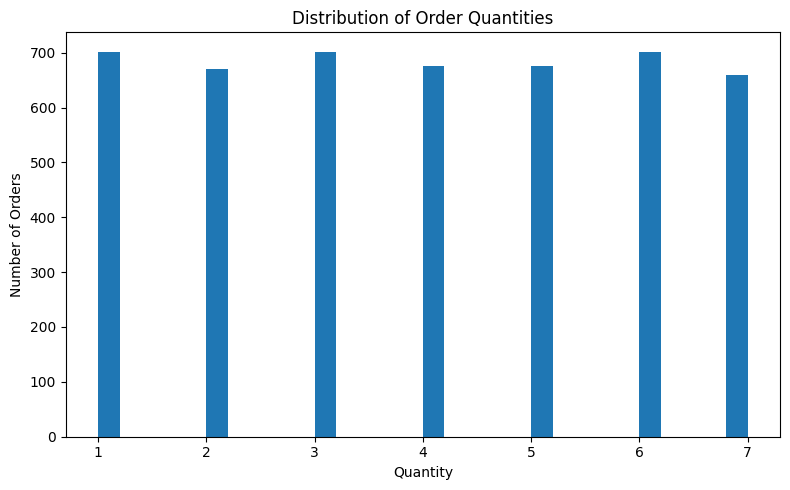

In [29]:
fig, ax = plt.subplots(figsize=(8, 5))

ax.hist(cleaned_orders["quantity"], bins=30)

ax.set_title("Distribution of Order Quantities")
ax.set_xlabel("Quantity")
ax.set_ylabel("Number of Orders")

fig.tight_layout()

fig.savefig(
    "figures/order_quantity_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Distribution of Order Quantities - Interpretation

The histogram shows the distribution of quantities ordered per transaction.

- Most orders contain a relatively small number of units.
- The quantities are distributed fairly evenly across the observed range.
- There is no strong concentration at a particular quantity.
- The difference between the most and least frequent quantities is relatively small.
- Overall, the distribution suggests consistent ordering patterns without a clear preference for a specific quantity.

## Unit Price vs Order Quantity

A scatter plot is used to examine the relationship between unit price and order quantity. This helps identify whether higher-priced products tend to be ordered in larger or smaller quantities and can also reveal unusual observations.

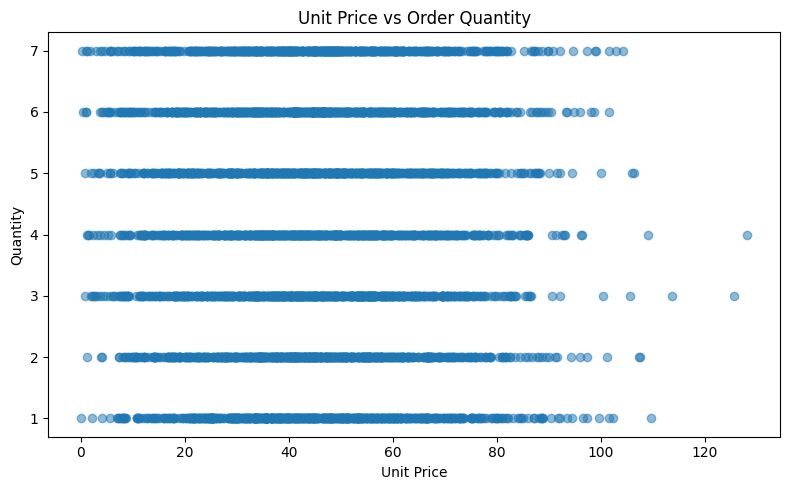

In [30]:
fig, ax = plt.subplots(figsize=(8, 5))

ax.scatter(
    cleaned_orders["unit_price"],
    cleaned_orders["quantity"],
    alpha=0.5
)

ax.set_title("Unit Price vs Order Quantity")
ax.set_xlabel("Unit Price")
ax.set_ylabel("Quantity")

fig.tight_layout()

fig.savefig(
    "figures/unit_price_vs_quantity.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Unit Price vs Order Quantity - Interpretation

The scatter plot shows the relationship between unit price and order quantity.

- The points are spread across different price and quantity values.
- There is no obvious strong linear relationship between unit price and quantity.
- Most observations are concentrated at lower-to-middle unit prices.
- Different quantities occur across a range of unit prices.
- A few higher-priced observations are also present but are less frequent.

Overall, the scatter plot does not show a clear pattern indicating that unit price strongly affects the quantity ordered.

## Orders Over Time

A line chart is used to examine how the number of orders changes over time. This helps identify overall trends, fluctuations, and periods with higher or lower order activity.

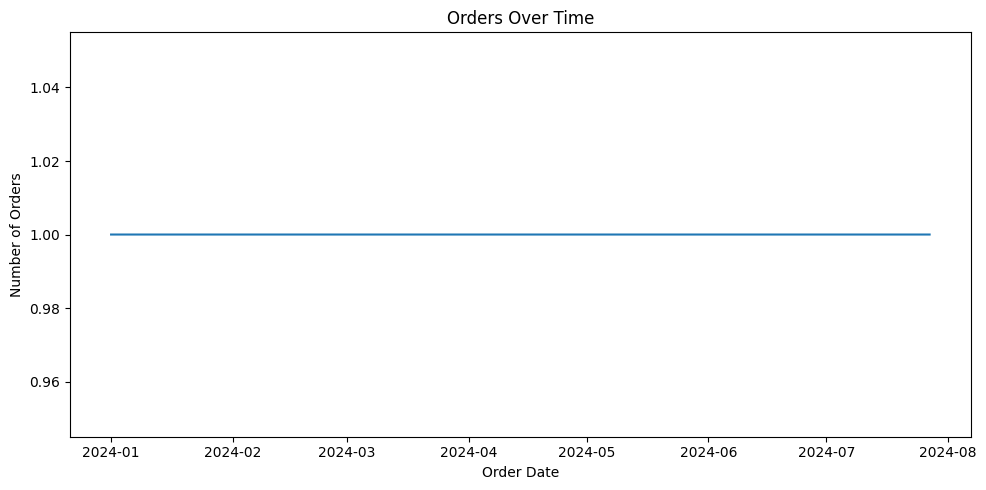

In [31]:
# Count orders by date
daily_orders = (
    cleaned_orders
    .groupby("order_date")
    .size()
)

fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(daily_orders.index, daily_orders.values)

ax.set_title("Orders Over Time")
ax.set_xlabel("Order Date")
ax.set_ylabel("Number of Orders")

fig.tight_layout()

fig.savefig(
    "figures/orders_over_time.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Orders Over Time - Interpretation

This line chart shows the number of orders recorded for each order date.

- The number of orders per day appears relatively consistent across the observed period.
- There are no major spikes or sudden drops in the daily order counts.
- This suggests a relatively stable ordering pattern in the cleaned dataset.
- However, the apparent flatness should be interpreted carefully because the number of records per date depends on how the original data is structured and aggregated.
- Further analysis of daily order counts can help identify trends, seasonality, or unusual fluctuations.

In [32]:
print("Total rows:", len(cleaned_orders))
print("Unique dates:", cleaned_orders["order_date"].nunique())

Total rows: 4788
Unique dates: 4788


## Orders Over Time - Interpretation

The analysis shows that the dataset contains 4,788 rows and 4,788 unique order dates. This means each record has a unique date, so each date appears only once in the dataset.

As a result, grouping the data by `order_date` produces a count of 1 for every date. Therefore, the Orders Over Time plot appears as a straight line at 1.

This flat line does not necessarily mean that the business received exactly one order per day. Instead, it indicates that each row in the dataset has a unique order date. Therefore, this visualization is not suitable for analyzing daily order volume unless multiple orders can occur on the same date.

### Key Insight
The dataset appears to contain one unique date per record, so `groupby("order_date").size()` returns 1 for every observation.

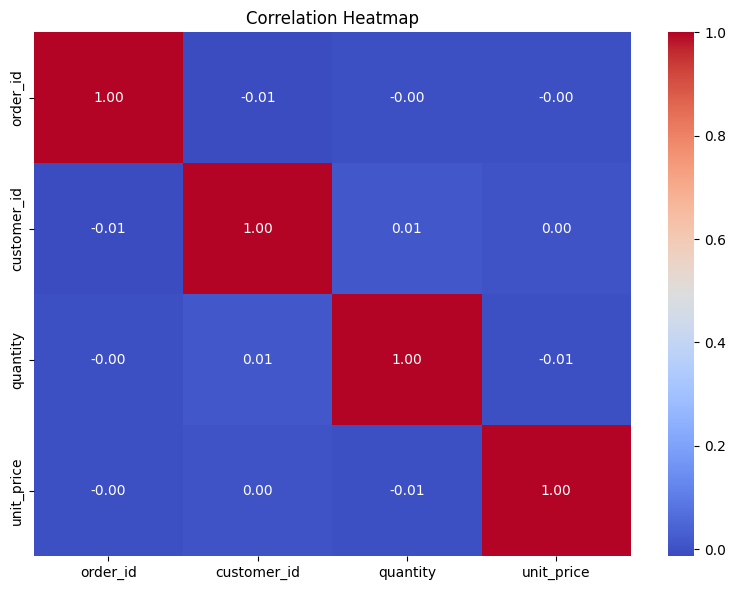

In [34]:
# Correlation matrix
correlation = cleaned_orders.select_dtypes(include="number").corr()

fig, ax = plt.subplots(figsize=(8, 6))

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    ax=ax
)

ax.set_title("Correlation Heatmap")

fig.tight_layout()

fig.savefig(
    "figures/correlation_heatmap.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Correlation Heatmap - Interpretation

The correlation heatmap shows the linear relationships between the numerical variables.

### Key Findings

- The correlation values between the variables are very close to **0**.
- This indicates that there is **little to no linear relationship** between order ID, customer ID, quantity, and unit price.
- The correlation between **quantity and unit price** is approximately **-0.01**, suggesting a very weak negative linear relationship.
- The correlation between **customer ID and quantity** is approximately **0.01**, indicating almost no linear relationship.
- Similarly, **customer ID and unit price** show almost no linear correlation.

### Conclusion

Overall, the heatmap suggests that these numerical variables do not have strong linear relationships with each other. However, correlation close to zero does **not necessarily mean that the variables are completely independent**; it only indicates the absence of a strong linear relationship.

In [36]:
cleaned_orders.columns

Index(['order_id', 'order_date', 'customer_id', 'product_category', 'quantity',
       'unit_price', 'region'],
      dtype='object')

## Unit Price Distribution by Category - Interpretation

This box plot compares the distribution of unit prices across different product categories.

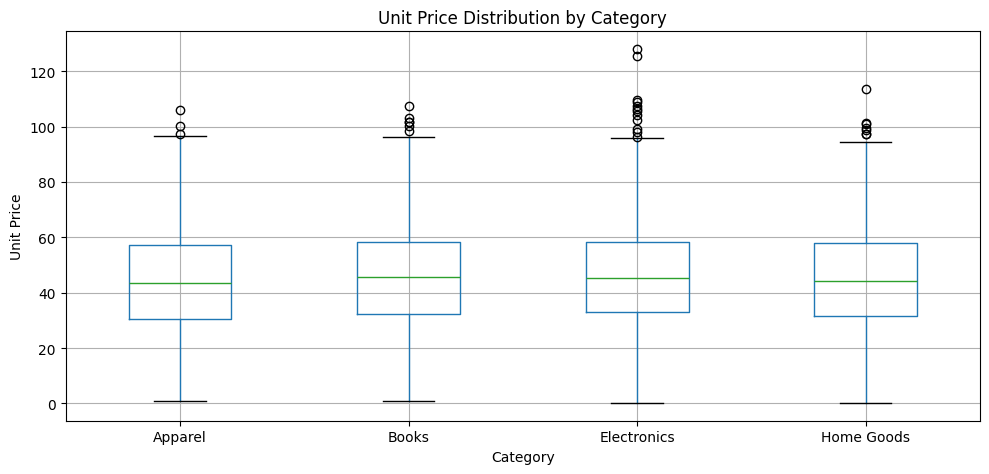

In [38]:
fig, ax = plt.subplots(figsize=(10, 5))

cleaned_orders.boxplot(
    column="unit_price",
    by="product_category",
    ax=ax
)

ax.set_title("Unit Price Distribution by Category")
ax.set_xlabel("Category")
ax.set_ylabel("Unit Price")

fig.suptitle("")  # Pandas ka default title remove karega
fig.tight_layout()

fig.savefig(
    "figures/unit_price_by_category.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Key Observations

- The median unit price is relatively similar across all categories.
- The middle 50% of prices (IQR) shows considerable overlap between categories.
- All categories contain both lower-priced and higher-priced products.
- Some high-price values appear as outliers in the categories.
- There is no strong visual evidence of a major difference in pricing between categories.

### Conclusion

Overall, unit prices are broadly similar across the product categories, with substantial overlap in their distributions. This suggests that category alone does not create a large difference in unit price in this dataset.

## Distribution of Orders by Region - Interpretation

This bar chart shows the distribution of orders across different regions.

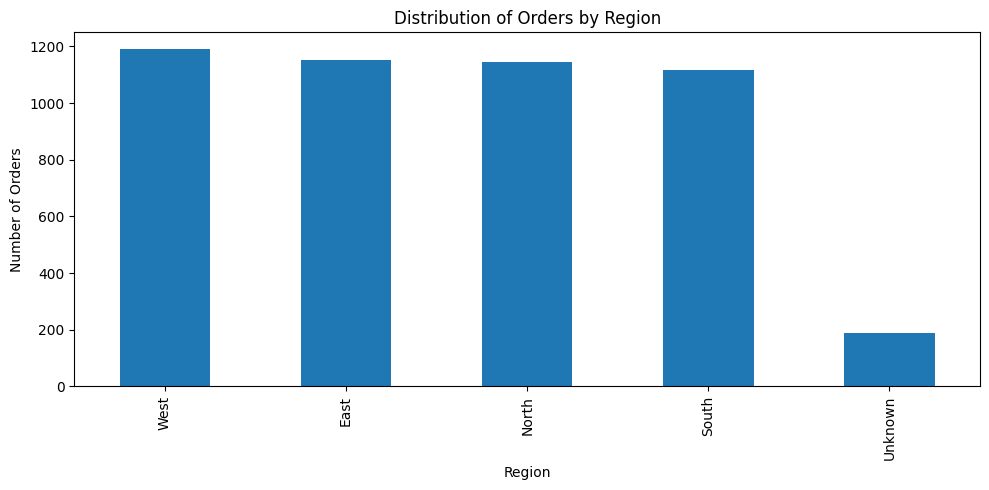

In [40]:
fig, ax = plt.subplots(figsize=(10, 5))

cleaned_orders["region"].value_counts().plot(
    kind="bar",
    ax=ax
)

ax.set_title("Distribution of Orders by Region")
ax.set_xlabel("Region")
ax.set_ylabel("Number of Orders")

fig.tight_layout()

fig.savefig(
    "figures/orders_by_region.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Key Findings:

1. **Balanced Regional Distribution**
   - Orders are distributed relatively evenly across the **North, South, East, and West** regions.
   - No single region dominates the overall order volume.
   - This indicates that orders are spread across different geographic areas.

2. **West Region**
   - The West region has the highest number of orders.
   - However, the difference compared with the other major regions is relatively small.
   - Therefore, West can be considered a slightly stronger region rather than a dominant one.

3. **North, East, and South Regions**
   - These regions have similar order counts.
   - Their comparable volumes suggest relatively consistent demand across these areas.

4. **Unknown Region**
   - A smaller number of orders have an **Unknown** region.
   - This indicates missing or unavailable regional information in the dataset.
   - These records should be investigated as a minor data-quality issue.

- There is no strong dependence on a single region.
- Similar order volumes across regions may indicate consistent demand across different locations.
- The slightly higher order count in the West region could be investigated further to understand whether it has any meaningful business advantage.

### Conclusion:

Overall, the order distribution is relatively balanced across the four major regions, with **West showing a slight lead**. The presence of some Unknown region values highlights a small data-quality issue that may be worth addressing before further regional analysis.

## Average Unit Price by Region - Interpretation

This bar chart compares the average unit price across different regions.

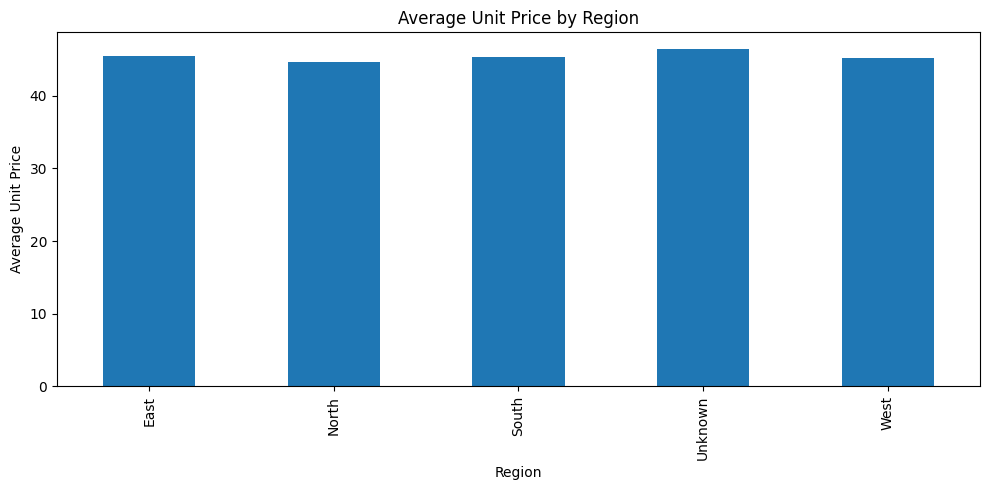

In [42]:
avg_price_region = (
    cleaned_orders
    .groupby("region")["unit_price"]
    .mean()
)

fig, ax = plt.subplots(figsize=(10, 5))

avg_price_region.plot(kind="bar", ax=ax)

ax.set_title("Average Unit Price by Region")
ax.set_xlabel("Region")
ax.set_ylabel("Average Unit Price")

fig.tight_layout()

fig.savefig(
    "figures/avg_unit_price_by_region.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Key Findings:

1. **Similar Average Prices Across Regions**
   - The average unit price is quite similar across all regions.
   - The values are approximately within the **$45-$47 range**.
   - This indicates that there is no major difference in average product prices between regions.

2. **Small Regional Differences**
   - Some regions have a slightly higher average price than others.
   - However, the differences are small and do not indicate a strong regional pricing pattern.
   - The **Unknown** region also has a similar average price to the known regions.

3. **Consistent Pricing**
   - Products appear to have relatively consistent average prices regardless of region.
   - This may indicate that the business follows a similar pricing approach across different geographic areas.

- Customers in different regions are purchasing products with **similar average unit prices**.
- There is no clear evidence of a region having significantly higher or lower-priced orders.
- A consistent average price across regions can make pricing and inventory planning easier.

### Conclusion:

Overall, the average unit price is **fairly consistent across all regions**, with only small differences between them. This suggests that **region does not have a major impact on the average unit price** in this dataset.

## Order Quantity Distribution by Region — Interpretation

The box plot shows the distribution of order quantities across different regions.

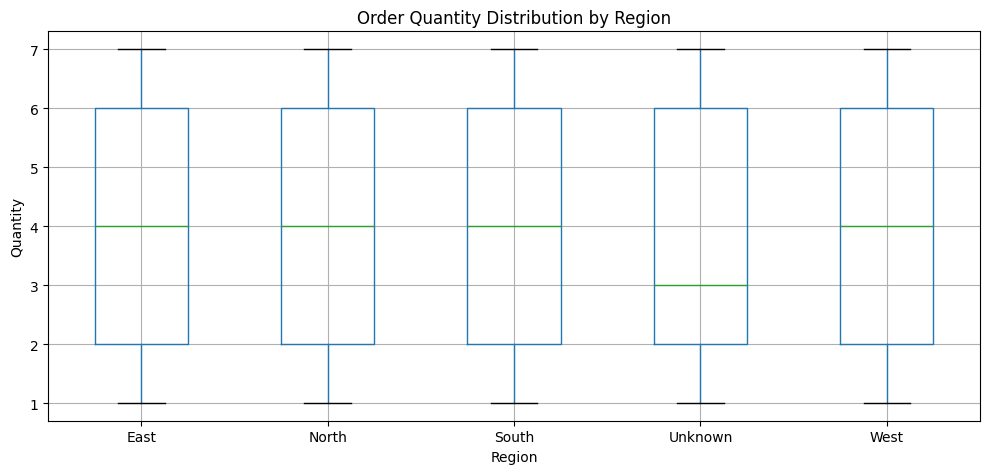

In [44]:
fig, ax = plt.subplots(figsize=(10, 5))

cleaned_orders.boxplot(
    column="quantity",
    by="region",
    ax=ax
)

ax.set_title("Order Quantity Distribution by Region")
ax.set_xlabel("Region")
ax.set_ylabel("Quantity")

fig.suptitle("")
fig.tight_layout()

fig.savefig(
    "figures/quantity_by_region.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Interpretation

All regions have a similar quantity distribution.
The minimum quantity is around 1 unit, while the maximum is around 7 units.
The median quantity is approximately 4 units across most regions.
The middle 50% of orders generally fall between 2 and 6 units.
There is no major difference in order quantity patterns between regions.
The similar distributions suggest that customers across regions tend to place orders of comparable sizes.
No significant outliers are visible in the regional quantity distributions.

Conclusion: Order quantities are fairly consistent across regions, with no clear evidence that customers in one region purchase substantially larger or smaller quantities than customers in another region.

## Visualization Summary

The visualizations provided an overview of the cleaned order dataset from different perspectives, including price, quantity, product category, time, and region.

- The **unit price distribution** showed that most prices are concentrated in the lower-to-middle range, with fewer higher-priced observations.
- The **product category distribution** showed that **Electronics** has the highest number of records, followed by **Home Goods, Apparel, and Books**.
- The **order quantity distribution** showed that orders generally contain a small number of units, with no extreme quantities.
- The **unit price vs. order quantity scatter plot** showed no obvious strong relationship between price and quantity.
- The **orders over time** visualization showed the distribution of records across the available dates. Since each date is unique in the cleaned dataset, it should not be interpreted as daily order volume without further aggregation.
- The **unit price by category** box plot helped compare price distributions across different product categories.
- The **orders by region** chart showed how records are distributed across geographic regions.
- The **average unit price by region** chart allowed comparison of pricing levels across regions.
- The **order quantity by region** box plot showed that quantity distributions are broadly similar across regions.

### Overall Conclusion

The visualizations provide a broad understanding of **pricing, quantities, product categories, time, and regional patterns** in the cleaned dataset. They also highlight areas that can be explored further through more detailed analysis.